## 데이터, 토크나이저 준비

- KoWiki 원문 사용

In [ ]:
!mkdir data
!mkdir models

In [ ]:
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip

--2026-09-15 01:34:32--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 99.84.237.123, 99.84.237.49, 99.84.237.107, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|99.84.237.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M   195MB/s    in 1.2s    

2026-09-15 01:34:33 (195 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]



In [ ]:
!mv kowiki.txt.zip /content/data

In [ ]:
%cd /content/data
!unzip kowiki.txt.zip

/content/data
Archive:  kowiki.txt.zip
  inflating: kowiki.txt              


In [ ]:
!pip install sentencepiece
!pip install tqdm
!conda install -c conda-forge ipywidgets

/bin/bash: line 1: conda: command not found


In [ ]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.11.0+cu128


## SentencePiece 토크나이저 학습

In [ ]:
import sentencepiece as spm
import os

corpus_file = '/content/data/kowiki.txt'
prefix = '/content/models/ko_8000'
vocab_size = 8000

spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size}"
    f" --model_type=bpe --max_sentence_length=999999"
    f" --pad_id=0 --pad_piece=[PAD]"
    f" --unk_id=1 --unk_piece=[UNK]"
    f" --bos_id=2 --bos_piece=[BOS]"
    f" --eos_id=3 --eos_piece=[EOS]"
    f" --user_defined_symbols=[SEP],[CLS],[MASK]"
)

True

In [ ]:
data_dir = '/content/data'
model_dir = '/content/models'

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_8000.model")

# 검증: 실제 vocab 크기와 특수 토큰 id 확인
print("vocab size:", vocab.get_piece_size())
for tok in ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[SEP]', '[CLS]', '[MASK]']:
    print(tok, "->", vocab.piece_to_id(tok))

vocab size: 8000
[PAD] -> 0
[UNK] -> 1
[BOS] -> 2
[EOS] -> 3
[SEP] -> 4
[CLS] -> 5
[MASK] -> 6


In [ ]:
vocab_size_total = vocab.get_piece_size()

vocab_list = []
for id in range(7, vocab_size_total):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

print(f"total vocab size: {vocab_size_total}")
print(f"일반 subword 개수: {len(vocab_list)}")  # 기대값: 7993 (8000 - 7)
print(vocab_list[:50])  # 앞부분만 미리보기

total vocab size: 8000
일반 subword 개수: 7993
['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동']


## 입력 토큰과 MLM 마스킹

두 문장을 `[CLS]`와 `[SEP]`로 묶고 MLM 학습용 마스크 만들기

In [ ]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
def make_bert_tokens(string_a, string_b, vocab):
    tokens = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
    return tokens

string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"

tokens_org = make_bert_tokens(string_a, string_b, vocab)
print(tokens_org)

# 특수 토큰이 vocab에 정확히 매핑되는지 검증
for special_tok in ["[CLS]", "[SEP]"]:
    tid = vocab.piece_to_id(special_tok)
    print(f"{special_tok} -> id {tid}")
    assert tid != vocab.piece_to_id("[UNK]"), f"{special_tok} 가 UNK로 매핑됩니다. 확인 필요"

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']
[CLS] -> id 5
[SEP] -> id 4


In [ ]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    tokens: [CLS] ... [SEP] ... [SEP] 형태의 토큰 리스트
    mask_cnt: 마스킹할 토큰 개수 (전체 토큰의 15% 기준으로 미리 계산)
    vocab_list: 특수토큰을 제외한 일반 subword 리스트 (랜덤 치환용)
    """
    # 1) 단어 단위(whole-word) 후보 인덱스 구성
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)

    tokens = copy.deepcopy(tokens)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:            # 80% [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9:          # 10% 원본 유지
                masked_token = tokens[index]
            else:                     # 10% 랜덤 토큰
                masked_token = random.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label


mask_cnt = max(1, int((len(tokens_org) - 3) * 0.15))
tokens, mask_idx, mask_label = create_pretrain_mask(tokens_org, mask_cnt, vocab_list)

print("tokens_org"); print(tokens_org, "\n")
print("tokens");     print(tokens, "\n")
print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '[MASK]', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '[MASK]', '[MASK]', '[MASK]', '▁십', '▁전', '짜', '리', '훗', '鎌', '뒷', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '[MA

In [ ]:
mask_cnt = max(1, int((len(tokens_org) - 3) * 0.15))

tokens = copy.deepcopy(tokens_org)
tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁대응', '▁번', '에', '▁삼', '십', '[MASK]', '▁둘', '째', '번', '[MASK]', '[MASK]', '′', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', 

In [ ]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [ ]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'],
 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'],
 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전']]

In [ ]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

In [ ]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        #######################################
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 5 62 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전'], ['▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']]
tokens_a: 22 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아']
tokens_b: 40 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']

current_chunk: 6 71 [['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내'], ['▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던'], ['▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '

In [ ]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [ ]:
def create_pretrain_instances(docs, doc_idx, doc, n_seq, mask_prob, vocab_list):
    """
    하나의 문서(doc)로부터 NSP+MLM pretrain instance들을 생성
    :param docs: 전체 문서 리스트 (다른 문서에서 랜덤 샘플링 하기 위해 필요)
    :param doc_idx: 현재 문서의 index (자기 자신을 랜덤 샘플링에서 제외하기 위해)
    :param doc: 현재 문서 (줄 단위로 토큰화된 리스트)
    :param n_seq: 최대 시퀀스 길이 ([CLS], [SEP], [SEP] 포함)
    :param mask_prob: mask 비율 (0.15)
    :param vocab_list: 특수토큰 제외 vocab 리스트
    """
    max_seq = n_seq - 3
    target_seq = max_seq

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if i == len(doc) - 1 or current_length >= target_seq:
            if current_chunk:
                # token a
                a_end = 1
                if 1 < len(current_chunk):
                    a_end = random.randrange(1, len(current_chunk))
                tokens_a = []
                for j in range(a_end):
                    tokens_a.extend(current_chunk[j])

                tokens_b = []
                # chunk가 1개뿐이거나 50% 확률이면 -> NotNext (다른 문서에서 랜덤 샘플링)
                if len(current_chunk) == 1 or random.random() < 0.5:
                    is_next = 0
                    tokens_b_len = target_seq - len(tokens_a)

                    random_doc_idx = doc_idx
                    while random_doc_idx == doc_idx:
                        random_doc_idx = random.randrange(0, len(docs))
                    random_doc = docs[random_doc_idx]

                    random_start = random.randrange(0, len(random_doc))
                    for j in range(random_start, len(random_doc)):
                        tokens_b.extend(random_doc[j])
                        if target_seq <= len(tokens_b):
                            break
                else:
                    is_next = 1
                    for j in range(a_end, len(current_chunk)):
                        tokens_b.extend(current_chunk[j])

                trim_tokens(tokens_a, tokens_b, max_seq)
                if len(tokens_a) == 0 or len(tokens_b) == 0:
                    # 극단적으로 짧아진 경우 skip (파이프라인 안정성)
                    current_chunk = []
                    current_length = 0
                    continue

                tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
                segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

                mask_cnt = max(1, int((len(tokens) - 3) * mask_prob))
                tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

                instance = {
                    "tokens": tokens,
                    "segment": segment,
                    "is_next": is_next,
                    "mask_idx": mask_idx,
                    "mask_label": mask_label
                }
                instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances

In [ ]:
# 테스트용 더미 문서 하나 더 생성
string2 = """이것은 다른 문서입니다
전혀 관련 없는 내용을 담고 있어요
NSP 테스트를 위한 두 번째 문서입니다"""
doc2 = [vocab.encode_as_pieces(line) for line in string2.split("\n")]

docs = [doc, doc2]  # 최소 2개 이상의 문서 필요
n_seq = 64
mask_prob = 0.15

instances = create_pretrain_instances(docs, 0, doc, n_seq, mask_prob, vocab_list)
for inst in instances:
    print(inst)
    print()

{'tokens': ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '[MASK]', '[MASK]', '[MASK]', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '[MASK]', '[MASK]', '[MASK]', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [15, 16, 17, 46, 47, 48, 57, 58, 59], 'mask_label': ['▁', '왠', '지', '▁백', '통', '화', '▁기', '쁨', '의']}

{'tokens': ['[CLS]', '▁절', '喜', '楠', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]', '▁전혀', '▁관련', '▁없는', '▁내용을', '▁담', '고', '▁있어', '요', '▁N', 'S', 'P', '▁테', '스트', '를', '▁위한', '[MASK]', '▁번째', '▁문서', '입', '니다', '[SEP]'], 'segment': [0, 0

## NSP와 MLM 사전학습 데이터 생성

문서를 문장 쌍으로 나누고 NSP와 MLM 정답을 함께 만들기

In [ ]:
corpus_file = '/content/data/kowiki.txt'

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total

3957761

In [ ]:
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

21 lines : ['▁지', '미', '▁카', '터']
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인', '권', '과', '▁중', '재', '▁역할', '에', '▁대한', '▁공', '로를', '▁인정', '받아', '▁노', '벨', '▁평화', '상을', '▁받', '게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미', '적', '분', '▁등의', '▁개념', '을', '▁다루', '는', '▁학', '문', '이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용', '해서', '▁공', '리로', '▁구성된', '▁추', '상', '적', '▁구조를', '▁연구', '하는', '▁학', '문', '으로', '▁여겨', '지', '기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조', '와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리', '학을', '▁비롯한', '▁다른', '▁학', '문', '들과', '▁깊', '은', '▁연', '관을', '▁맺', '고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학', '의', '▁분야', '들과', '는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지',

In [ ]:
# instance 생성 기능 확인
count = 5
docs_sample = []

with open(corpus_file, 'r') as in_f:
    doc = []
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":
            if 0 < len(doc):
                docs_sample.append(doc)
                doc = []
                if len(docs_sample) >= count:
                    break
        else:
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)

for doc_idx, doc in enumerate(docs_sample):
    instances = create_pretrain_instances(docs_sample, doc_idx, doc, n_test_seq, 0.15, vocab_list)
    print("doc:", len(doc), "instances:", len(instances))
    if instances:
        print(instances[0])
        print(instances[-1])
    print()

  0%|          | 0/3957761 [00:00<?, ?it/s]

doc: 21 instances: 14
{'tokens': ['[CLS]', '▁지', '미', '▁카', '터', '[SEP]', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '[MASK]', '[MASK]', '[MASK]', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '[MASK]', '▁(19', '7', '7', '년', '[MASK]', '▁1981', '년', ')', '이다', '.', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁마을', '에서', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [14, 15, 16, 34, 39, 57, 58, 59, 60], 'mask_label': ['▁주', '니어', '(,', '▁대통령', '▁~', '▁플', '레', '인', '스']}
{'tokens': ['[CLS]', '▁그는', '▁2002', '년', '▁말', '▁인', '권', '과', '▁중', '재', '▁역할', '에', '▁대한', '▁공', '로를', '▁인정', '받아', '▁노', '벨', '▁평화', '상을', '▁받', '게', '▁되었다', '.', '[SEP]', '▁대중', '문학', '이란', '▁상업', '성을', 

In [ ]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인 (tqdm total용)
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    # 1차 패스: 전체 문서를 docs 리스트로 구성 (빈 줄 = 문서 구분)
    docs = []
    with open(in_file, "r") as in_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt, desc="Loading docs"):
            line = line.strip()
            if line == "":
                if 0 < len(doc):
                    docs.append(doc)
                    doc = []
            else:
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)
        if 0 < len(doc):  # 마지막 문서 처리
            docs.append(doc)

    print(f"총 문서 수: {len(docs)}")

    # 2차 패스: docs를 순회하며 instance 생성 및 저장
    with open(out_file, "w") as out_f:
        for doc_idx, doc in enumerate(tqdm(docs, desc="Creating instances")):
            instances = create_pretrain_instances(docs, doc_idx, doc, n_seq, mask_prob, vocab_list)
            for instance in instances:
                out_f.write(json.dumps(instance, ensure_ascii=False))
                out_f.write("\n")

    return len(docs)

In [ ]:
pretrain_json_path = '/content/data/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

Loading docs:   0%|          | 0/3957761 [00:00<?, ?it/s]

총 문서 수: 502261


Creating instances:   0%|          | 0/502261 [00:00<?, ?it/s]

502261

In [ ]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

1095874

## 학습 데이터를 memmap으로 변환

큰 JSON 데이터를 고정 길이 배열로 저장해 효율적으로 읽음

In [ ]:
n_seq = 128
max_seq = n_seq - 3

memmap_dir = '/content/data'

enc_tokens = np.memmap(filename=f'{memmap_dir}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments   = np.memmap(filename=f'{memmap_dir}/segments.memmap',   mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename=f'{memmap_dir}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename=f'{memmap_dir}/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

# 메타 정보 저장 (나중에 memmap 재로딩 시 필요)
meta = {
    "total": total,
    "n_seq": n_seq,
    "dtype": "int32",
    "pad_id": vocab.piece_to_id("[PAD]"),
}
with open(f'{memmap_dir}/pretrain_meta.json', 'w') as f:
    json.dump(meta, f)

enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]

(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

In [ ]:
pad_id = vocab.piece_to_id("[PAD]")

# 전체 데이터 채우기 (테스트용 break 없이 전체 처리)
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        data = json.loads(line)

        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        assert len(enc_token) <= n_seq, f"토큰 길이 초과: {len(enc_token)} > {n_seq}"
        enc_token += [pad_id] * (n_seq - len(enc_token))

        # segment
        segment = data["segment"]
        assert len(segment) <= n_seq
        segment = segment + [0] * (n_seq - len(segment))

        # nsp label
        label_nsp = data["is_next"]

        # mlm label (mask 안 된 위치는 pad_id로 채워서 loss 계산 시 무시)
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=pad_id)
        if len(mask_idx) > 0:
            label_mlm[mask_idx] = mask_label

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

# 디스크에 확실히 반영
enc_tokens.flush()
segments.flush()
labels_nsp.flush()
labels_mlm.flush()

print("완료:", total, "개 instance 처리")

  0%|          | 0/1095874 [00:00<?, ?it/s]

완료: 1095874 개 instance 처리


In [ ]:
# 몇 개만 확인
for i in range(3):
    print("enc_token:", enc_tokens[i])
    print("segment:", segments[i])
    print("label_nsp:", labels_nsp[i])
    print("label_mlm:", labels_mlm[i])
    print()

enc_token: [   5    6    6  207 3707 3324 1042  104 3603 3679 3711    6    6    6
    6    6    6    6    6  160 3655    7 3622  203  241 3595 1114 3717
  788  243   49 3625  796  663 1648 3675 3675 3618    6 3009 3618 3609
   16 3592    4   18 3679  207 3707 3595 1756 3623 3639    6    6 3568
 3828  429 3733 3621 3619 1370   10 1607 3592 1756 3623   41 3637  830
 3617 1135   52 3592   13   81   87 1502 2247   25 3772 3866 3660 3624
 3806 3866 4189 3629 3772 3594  249 3718 1233   33   52 3592  479 3645
 3618  243 2780   14 1510  168 3870  414  166 1697 4283 3866 3696 3676
  593   21 5000  399 1928 3600  813   17 3592  307    6    6    6    6
    6    4]
segment: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
label_nsp: 1
label_mlm: [   0   18 3679    0    0    0    0    0    

In [ ]:
def build_pretrain_memmap(vocab, filename, n_seq, memmap_dir, count=None):
    """
    json 데이터를 읽어서 memmap 파일들을 생성 (한 번만 실행하면 됨)
    """
    pad_id = vocab.piece_to_id("[PAD]")

    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break

    enc_tokens = np.memmap(filename=f'{memmap_dir}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(filename=f'{memmap_dir}/segments.memmap',   mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=f'{memmap_dir}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=f'{memmap_dir}/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                break
            data = json.loads(line)

            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            assert len(enc_token) <= n_seq
            enc_token += [pad_id] * (n_seq - len(enc_token))

            segment = data["segment"] + [0] * (n_seq - len(data["segment"]))

            label_nsp = data["is_next"]

            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=pad_id)
            if len(mask_idx) > 0:
                label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    enc_tokens.flush(); segments.flush(); labels_nsp.flush(); labels_mlm.flush()

    # 메타정보 저장 (재로딩 시 shape 복원용)
    meta = {"total": total, "n_seq": n_seq, "pad_id": pad_id}
    with open(f'{memmap_dir}/pretrain_meta.json', 'w') as f:
        json.dump(meta, f)

    return total


def load_pretrain_memmap(memmap_dir):
    """
    이미 생성된 memmap 파일들을 읽기 전용으로 로드 (가볍고 빠름)
    """
    with open(f'{memmap_dir}/pretrain_meta.json', 'r') as f:
        meta = json.load(f)
    total, n_seq = meta["total"], meta["n_seq"]

    enc_tokens = np.memmap(filename=f'{memmap_dir}/enc_tokens.memmap', mode='r', dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(filename=f'{memmap_dir}/segments.memmap',   mode='r', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=f'{memmap_dir}/labels_nsp.memmap', mode='r', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=f'{memmap_dir}/labels_mlm.memmap', mode='r', dtype=np.int32, shape=(total, n_seq))

    return (enc_tokens, segments), (labels_nsp, labels_mlm), meta

In [ ]:
memmap_dir = '/content/data'

# 128000건 memmap으로 생성
total_built = build_pretrain_memmap(vocab, pretrain_json_path, 128, memmap_dir, count=128000)
print("생성된 데이터 수:", total_built)

  0%|          | 0/128000 [00:00<?, ?it/s]

생성된 데이터 수: 128000


In [ ]:
# 이후에는 이걸로 가볍게 로딩
pre_train_inputs, pre_train_labels, meta = load_pretrain_memmap(memmap_dir)
print(meta)

{'total': 128000, 'n_seq': 128, 'pad_id': 0}


In [ ]:
# 처음과 마지막 확인
(pre_train_inputs[0][0], pre_train_inputs[0][-1],
 pre_train_inputs[1][0], pre_train_inputs[1][-1],
 pre_train_labels[0][0], pre_train_labels[0][-1],
 pre_train_labels[1][0], pre_train_labels[1][-1])

(memmap([   5,    6,    6,  207, 3707, 3324, 1042,  104, 3603, 3679, 3711,
            6,    6,    6,    6,    6,    6,    6,    6,  160, 3655,    7,
         3622,  203,  241, 3595, 1114, 3717,  788,  243,   49, 3625,  796,
          663, 1648, 3675, 3675, 3618,    6, 3009, 3618, 3609,   16, 3592,
            4,   18, 3679,  207, 3707, 3595, 1756, 3623, 3639,    6,    6,
         3568, 3828,  429, 3733, 3621, 3619, 1370,   10, 1607, 3592, 1756,
         3623,   41, 3637,  830, 3617, 1135,   52, 3592,   13,   81,   87,
         1502, 2247,   25, 3772, 3866, 3660, 3624, 3806, 3866, 4189, 3629,
         3772, 3594,  249, 3718, 1233,   33,   52, 3592,  479, 3645, 3618,
          243, 2780,   14, 1510,  168, 3870,  414,  166, 1697, 4283, 3866,
         3696, 3676,  593,   21, 5000,  399, 1928, 3600,  813,   17, 3592,
          307,    6,    6,    6,    6,    6,    4], dtype=int32),
 memmap([   5,  313, 3741, 3590,   21, 3888,   32, 3774,  202,  391, 3939,
           73, 1208,    6,    6,  

## miniBERT 모델

In [ ]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수 (BERT에서 사용)
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0), shape (bs, 1, n_seq)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수 (BERT에서는 사용하지 않음, GPT류 decoder용으로 남겨둔 범용 유틸)
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

In [ ]:
GELU_CONST = math.sqrt(2 / math.pi)

def gelu(x):
    """
    gelu activation 함수 (tanh 근사, BERT 원 구현과 동일한 공식)
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(GELU_CONST * (x + 0.044715 * torch.pow(x, 3))))

In [ ]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    :return: (tensor) -> tensor 형태의 initializer 함수
    """
    def _init(tensor):
        return torch.nn.init.trunc_normal_(tensor, mean=0.0, std=stddev)
    return _init


def bias_initializer():
    """
    bias initializer 생성
    :return: (tensor) -> tensor 형태의 initializer 함수
    """
    def _init(tensor):
        return torch.nn.init.zeros_(tensor)
    return _init

In [ ]:
class Config(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

In [ ]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        assert inputs.max() < self.n_vocab and inputs.min() >= 0, \
            f"token id가 vocab 범위를 벗어났습니다: min={inputs.min().item()}, max={inputs.max().item()}, n_vocab={self.n_vocab}"
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs

In [ ]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        :param inputs: (bs, n_seq) 토큰 id (position 계산용, 값 자체는 사용 안 함)
        """
        bs, n_seq = inputs.shape
        position = torch.arange(n_seq, device=inputs.device).unsqueeze(0).expand(bs, -1)
        embed = self.embedding(position)
        return embed

In [ ]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32, device=Q.device))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

In [ ]:
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        assert self.n_head * self.d_head == self.d_model or True, \
            "일반적으로 n_head * d_head == d_model 이 되도록 config를 구성하는 것을 권장합니다."

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

        # BERT 스타일 초기화 적용
        for linear in [self.W_Q, self.W_K, self.W_V, self.W_O]:
            nn.init.trunc_normal_(linear.weight, std=0.02)
            nn.init.zeros_(linear.bias)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)

        return attn_out

In [ ]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

    def forward(self, inputs):
        ff_val = self.W_2(gelu(self.W_1(inputs)))
        return ff_val

In [ ]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

In [ ]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        super(BERT, self).__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        nn.init.trunc_normal_(self.segment.weight, std=0.02)

        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)]
        )
        self.dropout = nn.Dropout(config.dropout)

        # 전체 Linear 레이어에 대해 BERT 스타일 초기화 일괄 적용
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, enc_tokens, segments):
        assert segments.max() <= 1 and segments.min() >= 0, "segment id는 0 또는 1이어야 합니다."

        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

In [ ]:
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

        nn.init.trunc_normal_(self.dense1.weight, std=0.02)
        nn.init.zeros_(self.dense1.bias)
        nn.init.trunc_normal_(self.dense2.weight, std=0.02)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits (CrossEntropyLoss가 내부에서 softmax 처리)

In [ ]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        outputs_nsp = self.pooled_output(logits_cls)  # raw logits
        outputs_mlm = logits_lm                        # raw logits

        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

In [ ]:
def lm_loss(y_true, y_pred, pad_id=0, mlm_weight=20.0):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    :param pad_id: pad(마스킹 안 된 위치) id
    :param mlm_weight: NSP loss와의 스케일 균형을 위한 가중치
    """
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    mask = (y_true != pad_id).float().view(-1)
    loss = loss * mask
    denom = mask.sum().clamp(min=1)
    return (loss.sum() / denom) * mlm_weight

In [ ]:
def lm_acc(y_true, y_pred, pad_id=0):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    :param pad_id: pad(마스킹 안 된 위치) id
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()
    mask = (y_true != pad_id).float()
    matches = matches * mask
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

In [ ]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            progress = min(1.0, progress)  # 학습 step이 train_steps를 넘어가도 안전하게
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        매 학습 step마다 호출: step_num 증가 + optimizer의 lr을 실제로 갱신
        """
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
        return lr

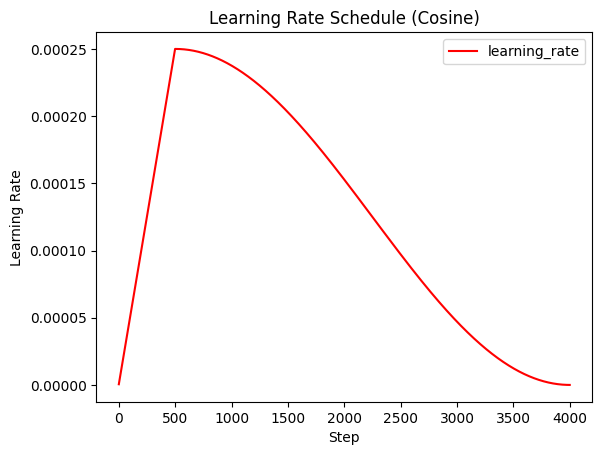

In [ ]:
# compute lr (시각화 테스트 시엔 optimizer=None으로 둬도 무방)
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

In [ ]:
config = Config({
    "d_model": 128,
    "n_head": 2,
    "d_head": 64,      # n_head * d_head = 128 = d_model
    "dropout": 0.1,
    "d_ff": 256,
    "layernorm_epsilon": 1e-6,
    "n_layer": 2,
    "n_seq": 128,
    "n_vocab": vocab.get_piece_size(),   # 8000
    "i_pad": vocab.piece_to_id("[PAD]"),
})

In [ ]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [ ]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,000
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

## 사전학습

In [ ]:
epochs = 10
batch_size = 64

train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
learning_rate_scheduler = CosineSchedule(
    optimizer=None,  # 아래에서 optimizer 생성 후 다시 연결
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10)
)
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)
learning_rate_scheduler.optimizer = optimizer  # scheduler가 내부에서 optimizer의 lr을 갱신하도록 연결

train_steps: 20000


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

pad_id = config.i_pad  # 하드코딩된 0 대신 config에서 가져옴

history = {
    'total_loss': [],
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.long()

        # 범위를 벗어난 값이 있다면 전처리 버그이므로 조용히 clamp하지 않고 바로 확인
        assert labels_mlm_batch.max() < config.n_vocab, \
            f"mlm label이 vocab 범위를 벗어났습니다: {labels_mlm_batch.max().item()}"

        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # 이전 단계에서 정의한 커스텀 loss/acc 함수 사용
        loss_nsp = F.cross_entropy(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, pad_id=pad_id, mlm_weight=20.0)

        total_loss_batch = loss_nsp + loss_mlm

        total_loss_batch.backward()

        # lr을 먼저 계산/반영한 뒤 optimizer.step() 호출 (scheduler가 optimizer의 lr을 직접 갱신함)
        learning_rate_scheduler.step()
        optimizer.step()

        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = lm_acc(labels_mlm_batch, logits_mlm, pad_id=pad_id)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    n_batches = len(train_dataloader)
    history['total_loss'].append(total_loss / n_batches)
    history['nsp_loss'].append(total_nsp_loss / n_batches)
    history['mlm_loss'].append(total_mlm_loss / n_batches)
    history['nsp_acc'].append(total_nsp_acc / n_batches)
    history['mlm_acc'].append(total_mlm_acc / n_batches)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / n_batches:.4f}, "
          f"NSP Loss: {total_nsp_loss / n_batches:.4f}, MLM Loss: {total_mlm_loss / n_batches:.4f}, "
          f"NSP Acc: {total_nsp_acc / n_batches:.4f}, MLM Acc: {total_mlm_acc / n_batches:.4f}")

    torch.save(pre_train_model.state_dict(), f"{model_dir}/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/10 - Loss: 151.4723, NSP Loss: 0.6147, MLM Loss: 150.8576, NSP Acc: 0.6829, MLM Acc: 0.0697
Epoch 2/10 - Loss: 134.7048, NSP Loss: 0.4734, MLM Loss: 134.2314, NSP Acc: 0.7415, MLM Acc: 0.1178
Epoch 3/10 - Loss: 128.7232, NSP Loss: 0.4381, MLM Loss: 128.2851, NSP Acc: 0.7638, MLM Acc: 0.1328
Epoch 4/10 - Loss: 124.8427, NSP Loss: 0.4210, MLM Loss: 124.4217, NSP Acc: 0.7772, MLM Acc: 0.1401
Epoch 5/10 - Loss: 119.9446, NSP Loss: 0.4192, MLM Loss: 119.5254, NSP Acc: 0.7816, MLM Acc: 0.1490
Epoch 6/10 - Loss: 114.7836, NSP Loss: 0.4157, MLM Loss: 114.3679, NSP Acc: 0.7855, MLM Acc: 0.1599
Epoch 7/10 - Loss: 111.6439, NSP Loss: 0.4088, MLM Loss: 111.2351, NSP Acc: 0.7913, MLM Acc: 0.1682
Epoch 8/10 - Loss: 109.2021, NSP Loss: 0.4036, MLM Loss: 108.7986, NSP Acc: 0.7935, MLM Acc: 0.1746
Epoch 9/10 - Loss: 108.0954, NSP Loss: 0.4006, MLM Loss: 107.6948, NSP Acc: 0.7964, MLM Acc: 0.1776
Epoch 10/10 - Loss: 107.7234, NSP Loss: 0.3981, MLM Loss: 107.3253, NSP Acc: 0.7980, MLM Acc: 0.1788

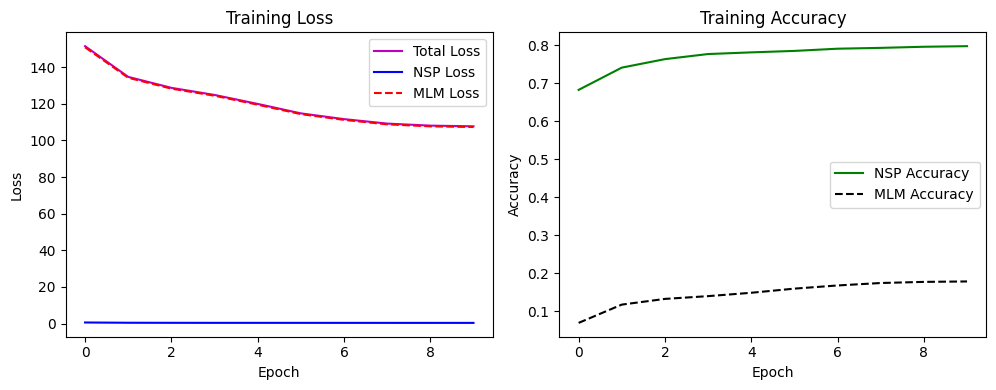

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(history['total_loss'], 'm-', label='Total Loss')
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')

plt.subplot(1, 3, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy')

plt.tight_layout()
plt.show()

## 학습 결과 확인

마스크 예측, 문장 연결성, 임베딩 유사도로 학습 결과를 확인

In [ ]:
def predict_mask(model, vocab, sentence, config, device, top_k=5):
    """
    문장에서 [MASK] 토큰이 무엇일지 예측
    :param sentence: 문자열, 마스킹하고 싶은 단어 위치에 이미 "[MASK]"가 포함되어 있어야 함
                      예: "나는 오늘 [MASK] 에 갔다"
    """
    model.eval()

    # sentence를 토큰화하되, "[MASK]"는 그대로 유지
    pieces = []
    for word in sentence.split(" "):
        if word == "[MASK]":
            pieces.append("[MASK]")
        else:
            pieces.extend(vocab.encode_as_pieces(word))

    tokens = ["[CLS]"] + pieces + ["[SEP]"]
    token_ids = [vocab.piece_to_id(p) for p in tokens]
    mask_pos = [i for i, t in enumerate(tokens) if t == "[MASK]"]

    n_seq = config.n_seq
    pad_id = config.i_pad
    token_ids = token_ids[:n_seq] + [pad_id] * max(0, n_seq - len(token_ids))
    segment = [0] * n_seq

    enc_tokens = torch.tensor([token_ids], dtype=torch.long).to(device)
    segments = torch.tensor([segment], dtype=torch.long).to(device)

    with torch.no_grad():
        _, logits_mlm = model(enc_tokens, segments)

    print(f"입력: {sentence}")
    for pos in mask_pos:
        probs = F.softmax(logits_mlm[0, pos], dim=-1)
        top_probs, top_ids = probs.topk(top_k)
        preds = [(vocab.id_to_piece(idx.item()), round(p.item(), 4)) for idx, p in zip(top_ids, top_probs)]
        print(f"  [MASK] (위치 {pos}) 예측 top-{top_k}: {preds}")
    print()


predict_mask(pre_train_model, vocab, "이순신 은 [MASK] 시대 의 명장 이다", config, device)
predict_mask(pre_train_model, vocab, "대한민국 의 수도 는 [MASK] 이다", config, device)

입력: 이순신 은 [MASK] 시대 의 명장 이다
  [MASK] (위치 5) 예측 top-5: [('▁중', 0.0254), ('▁아들', 0.0233), ('▁이', 0.0228), ('▁-', 0.0178), ('▁그의', 0.0161)]

입력: 대한민국 의 수도 는 [MASK] 이다
  [MASK] (위치 6) 예측 top-5: [('▁다음과', 0.1427), ('▁다음', 0.0634), ('▁다음을', 0.0493), ('▁일본의', 0.0343), ('▁대한민국의', 0.0256)]



In [ ]:
def predict_nsp(model, vocab, sentence_a, sentence_b, config, device):
    model.eval()

    tokens = ["[CLS]"] + vocab.encode_as_pieces(sentence_a) + ["[SEP]"] + vocab.encode_as_pieces(sentence_b) + ["[SEP]"]
    token_ids = [vocab.piece_to_id(p) for p in tokens]

    sep_pos = tokens.index("[SEP]")
    segment = [0] * (sep_pos + 1) + [1] * (len(tokens) - sep_pos - 1)

    n_seq = config.n_seq
    pad_id = config.i_pad
    token_ids = token_ids[:n_seq] + [pad_id] * max(0, n_seq - len(token_ids))
    segment = segment[:n_seq] + [0] * max(0, n_seq - len(segment))

    enc_tokens = torch.tensor([token_ids], dtype=torch.long).to(device)
    segments = torch.tensor([segment], dtype=torch.long).to(device)

    with torch.no_grad():
        logits_nsp, _ = model(enc_tokens, segments)
        prob = F.softmax(logits_nsp, dim=-1)[0]

    print(f"문장 A: {sentence_a}")
    print(f"문장 B: {sentence_b}")
    print(f"IsNext 확률: {prob[1].item():.4f} / NotNext 확률: {prob[0].item():.4f}")
    print()


# 실제로 이어지는 문장 쌍
predict_nsp(pre_train_model, vocab, "이순신은 조선의 명장이다", "임진왜란에서 큰 활약을 했다", config, device)
# 서로 무관한 문장 쌍
predict_nsp(pre_train_model, vocab, "이순신은 조선의 명장이다", "피자는 이탈리아 음식이다", config, device)

문장 A: 이순신은 조선의 명장이다
문장 B: 임진왜란에서 큰 활약을 했다
IsNext 확률: 0.4522 / NotNext 확률: 0.5478

문장 A: 이순신은 조선의 명장이다
문장 B: 피자는 이탈리아 음식이다
IsNext 확률: 0.0952 / NotNext 확률: 0.9048



In [ ]:
def nearest_tokens(model, vocab, word, top_k=10):
    embedding_weight = model.bert.embedding.shared_weights.detach().cpu()  # (n_vocab, d_model)

    pieces = vocab.encode_as_pieces(word)
    if not pieces:
        print("토큰화 실패")
        return
    token_id = vocab.piece_to_id(pieces[0])

    target_vec = embedding_weight[token_id]
    sims = F.cosine_similarity(embedding_weight, target_vec.unsqueeze(0), dim=-1)
    top_sims, top_ids = sims.topk(top_k + 1)  # 자기 자신 포함해서 +1

    print(f"'{word}' (토큰: {pieces[0]}) 와 유사한 토큰:")
    for idx, sim in zip(top_ids, top_sims):
        print(f"  {vocab.id_to_piece(idx.item())}: {sim.item():.4f}")
    print()


nearest_tokens(pre_train_model, vocab, "대한민국")
nearest_tokens(pre_train_model, vocab, "왕")

'대한민국' (토큰: ▁대한민국) 와 유사한 토큰:
  ▁대한민국: 1.0000
  ▁대한민국의: 0.4877
  ▁대전: 0.4285
  ▁선거: 0.4191
  ▁국회의원: 0.4108
  ▁조선민주주의인민공화국: 0.4098
  ▁서울특별시: 0.4026
  ▁제: 0.4022
  ▁일본의: 0.3899
  ▁한국의: 0.3874
  ▁경기도: 0.3812

'왕' (토큰: ▁왕) 와 유사한 토큰:
  ▁왕: 1.0000
  ▁어머니: 0.4155
  ▁귀족: 0.4107
  ▁황: 0.4028
  ▁황제: 0.3962
  ▁백: 0.3833
  ▁아버지: 0.3821
  ▁공작: 0.3816
  ▁로마: 0.3736
  ▁제국: 0.3716
  ▁시대: 0.3537



### count=128000 제한을 없애고 에포크 수 늘리기
+ 데이터를 val, train으로 분리한 후 early stopping 적용하기

In [ ]:
memmap_dir = '/content/data'

total_built = build_pretrain_memmap(vocab, pretrain_json_path, 128, memmap_dir, count=None)
print("생성된 데이터 수:", total_built)

  0%|          | 0/1095874 [00:00<?, ?it/s]

생성된 데이터 수: 1095874


In [ ]:
pre_train_inputs, pre_train_labels, meta = load_pretrain_memmap(memmap_dir)
print(meta)

{'total': 1095874, 'n_seq': 128, 'pad_id': 0}


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split


class PretrainDataset(Dataset):
    def __init__(self, inputs, labels):
        self.enc_tokens = inputs[0]
        self.segments = inputs[1]
        self.labels_nsp = labels[0]
        self.labels_mlm = labels[1]

    def __len__(self):
        return len(self.enc_tokens)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.enc_tokens[idx].copy()).long(),
            torch.from_numpy(self.segments[idx].copy()).long(),
            torch.tensor(self.labels_nsp[idx]).long(),
            torch.from_numpy(self.labels_mlm[idx].copy()).long()
        )

In [ ]:
batch_size = 64

pre_train_inputs, pre_train_labels, meta = load_pretrain_memmap(memmap_dir)

print(meta)

# Dataset 생성
full_dataset = PretrainDataset(pre_train_inputs, pre_train_labels)

# train / validation 분리
val_ratio = 0.05

total_len = len(full_dataset)
val_len = int(total_len * val_ratio)
train_len = total_len - val_len

train_subset, val_subset = random_split(full_dataset, [train_len, val_len], generator=torch.Generator().manual_seed(random_seed))

train_dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

val_dataloader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f"train: {train_len:,}, val: {val_len:,}")

{'total': 1095874, 'n_seq': 128, 'pad_id': 0}
train: 1,041,081, val: 54,793


In [ ]:
epochs = 1000
batch_size = 64

train_steps = len(train_dataloader) * epochs

print("train batches:", len(train_dataloader))
print("train_steps:", train_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10)
)

train batches: 16267
train_steps: 16267000


In [ ]:
class EarlyStopping:
    """
    validation loss가 patience epoch 동안 개선되지 않으면 학습을 중단
    """
    def __init__(self, patience=3, min_delta=0.0, save_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def step(self, val_loss, model=None):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.save_path is not None and model is not None:
                torch.save(model.state_dict(), self.save_path)
                print(f"  -> best model 저장 (val_loss={val_loss:.4f})")
        else:
            self.counter += 1
            print(f"  -> 개선 없음 ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [ ]:
# validation loop 함수
def evaluate(model, dataloader, device, pad_id, mlm_weight=20.0):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

            enc_tokens_batch = enc_tokens_batch.to(device)
            segments_batch = segments_batch.to(device)
            labels_nsp_batch = labels_nsp_batch.long().to(device)
            labels_mlm_batch = labels_mlm_batch.long().to(device)

            logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

            loss_nsp = F.cross_entropy(logits_nsp, labels_nsp_batch)
            loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, pad_id=pad_id, mlm_weight=mlm_weight)

            total_loss += (loss_nsp + loss_mlm).item()

    return total_loss / len(dataloader)

In [ ]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,000
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

In [ ]:
epochs = 1000

train_steps = len(train_dataloader) * epochs

print("train batches:", len(train_dataloader))
print("train_steps:", train_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10)
)

train batches: 16267
train_steps: 16267000


In [ ]:
# 학습 루프에 early stopping 통합
epochs = 1000
early_stopper = EarlyStopping(patience=3, min_delta=0.01, save_path=f"{model_dir}/bert_best.pt")

history = {'total_loss': [], 'val_loss': [], 'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

for epoch in range(epochs):
    pre_train_model.train()

    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        # CPU → GPU
        enc_tokens_batch = enc_tokens_batch.to(device)
        segments_batch = segments_batch.to(device)
        labels_nsp_batch = labels_nsp_batch.long().to(device)
        labels_mlm_batch = labels_mlm_batch.long().to(device)

        optimizer.zero_grad()

        # Forward
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # NSP Loss
        loss_nsp = F.cross_entropy(logits_nsp, labels_nsp_batch)

        # MLM Loss
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, pad_id=pad_id, mlm_weight=20.0)

        # Total Loss
        total_loss_batch = loss_nsp + loss_mlm

        # Backpropagation
        total_loss_batch.backward()

        # Optimizer
        optimizer.step()
        learning_rate_scheduler.step()

        # 통계
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_acc += (logits_nsp.argmax(-1) == labels_nsp_batch).float().mean().item()
        total_mlm_acc += lm_acc(labels_mlm_batch, logits_mlm, pad_id=pad_id).item()

    # Validation
    n_batches = len(train_dataloader)
    val_loss = evaluate(pre_train_model, val_dataloader, device, pad_id)

    # History
    history['total_loss'].append(total_loss / n_batches)
    history['val_loss'].append(val_loss)
    history['nsp_loss'].append(total_nsp_loss / n_batches)
    history['mlm_loss'].append(total_mlm_loss / n_batches)
    history['nsp_acc'].append(total_nsp_acc / n_batches)
    history['mlm_acc'].append(total_mlm_acc / n_batches)

    # 출력
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {total_loss/n_batches:.4f}, Val Loss: {val_loss:.4f}, NSP Acc: {total_nsp_acc/n_batches:.4f}, MLM Acc: {total_mlm_acc/n_batches:.4f}")

    # Early Stopping
    if early_stopper.step(val_loss, pre_train_model):
        print(f"Early stopping at epoch {epoch+1}")
        break

Epoch 1/1000 - Train Loss: 169.6385, Val Loss: 154.1850, NSP Acc: 0.6250, MLM Acc: 0.0672
  -> best model 저장 (val_loss=154.1850)
Epoch 2/1000 - Train Loss: 147.9329, Val Loss: 144.8227, NSP Acc: 0.6278, MLM Acc: 0.0412
  -> best model 저장 (val_loss=144.8227)
Epoch 3/1000 - Train Loss: 143.7161, Val Loss: 141.4106, NSP Acc: 0.6283, MLM Acc: 0.0710
  -> best model 저장 (val_loss=141.4106)
Epoch 4/1000 - Train Loss: 140.3286, Val Loss: 137.9302, NSP Acc: 0.6351, MLM Acc: 0.0980
  -> best model 저장 (val_loss=137.9302)
Epoch 5/1000 - Train Loss: 136.9939, Val Loss: 134.7200, NSP Acc: 0.6328, MLM Acc: 0.1120
  -> best model 저장 (val_loss=134.7200)
Epoch 6/1000 - Train Loss: 133.6435, Val Loss: 131.3802, NSP Acc: 0.6284, MLM Acc: 0.1222
  -> best model 저장 (val_loss=131.3802)
Epoch 7/1000 - Train Loss: 130.5601, Val Loss: 128.3941, NSP Acc: 0.6478, MLM Acc: 0.1291
  -> best model 저장 (val_loss=128.3941)
Epoch 8/1000 - Train Loss: 127.7950, Val Loss: 125.3313, NSP Acc: 0.6828, MLM Acc: 0.1343
  -> be

학습이 오래 걸려 40 EPOCH에서 중단시킴

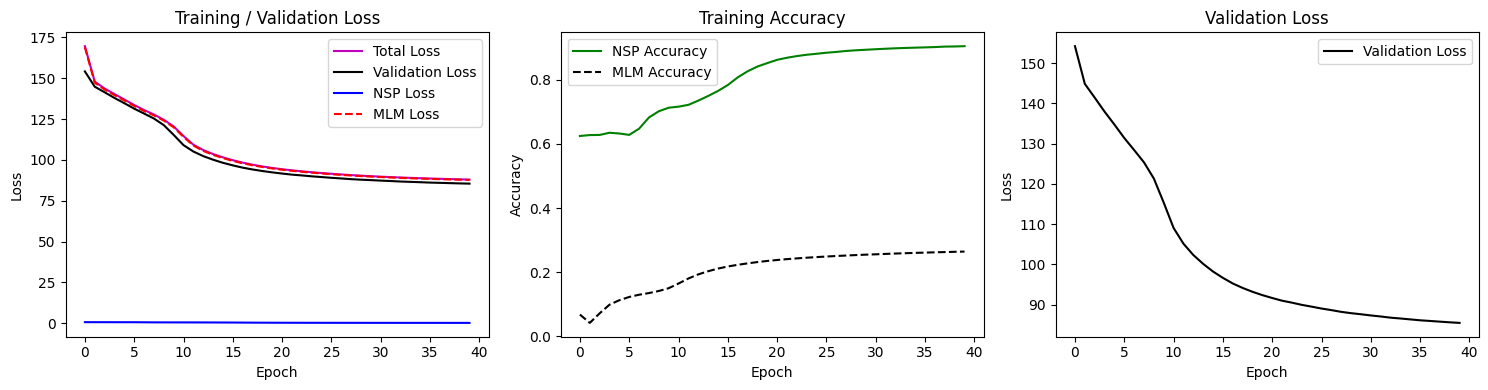

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

# Loss
plt.subplot(1, 3, 1)

plt.plot(history['total_loss'], 'm-', label='Total Loss')
plt.plot(history['val_loss'], 'k-', label='Validation Loss')
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training / Validation Loss')

# Accuracy
plt.subplot(1, 3, 2)

plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy')

# Validation Loss만 따로 표시
plt.subplot(1, 3, 3)

plt.plot(history['val_loss'], 'k-', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Validation Loss')

plt.tight_layout()
plt.show()

In [ ]:
predict_mask(pre_train_model, vocab, "이순신 은 [MASK] 시대 의 명장 이다", config, device)
predict_mask(pre_train_model, vocab, "대한민국 의 수도 는 [MASK] 이다", config, device)

입력: 이순신 은 [MASK] 시대 의 명장 이다
  [MASK] (위치 5) 예측 top-5: [('▁조선', 0.1823), ('▁이', 0.1084), ('▁전국', 0.0942), ('▁고려', 0.071), ('▁우리', 0.0688)]

입력: 대한민국 의 수도 는 [MASK] 이다
  [MASK] (위치 6) 예측 top-5: [('▁다음을', 0.0393), ('▁교황', 0.0363), ('▁현재', 0.0151), ('▁성', 0.0127), ('▁없다', 0.0108)]



In [ ]:
# 실제로 이어지는 문장 쌍
predict_nsp(pre_train_model, vocab, "이순신은 조선의 명장이다", "임진왜란에서 큰 활약을 했다", config, device)
# 서로 무관한 문장 쌍
predict_nsp(pre_train_model, vocab, "이순신은 조선의 명장이다", "피자는 이탈리아 음식이다", config, device)

문장 A: 이순신은 조선의 명장이다
문장 B: 임진왜란에서 큰 활약을 했다
IsNext 확률: 0.6105 / NotNext 확률: 0.3895

문장 A: 이순신은 조선의 명장이다
문장 B: 피자는 이탈리아 음식이다
IsNext 확률: 0.0223 / NotNext 확률: 0.9777



In [ ]:
nearest_tokens(pre_train_model, vocab, "대한민국")
nearest_tokens(pre_train_model, vocab, "왕")

'대한민국' (토큰: ▁대한민국) 와 유사한 토큰:
  ▁대한민국: 1.0000
  ▁조선민주주의인민공화국: 0.6988
  ▁한국: 0.6735
  ▁미국: 0.6466
  ▁대한민국의: 0.6108
  ▁일본: 0.6102
  ▁중국: 0.5903
  ▁중화인민공화국: 0.5671
  ▁영국: 0.5357
  ▁중화: 0.5269
  ▁충청남도: 0.5109

'왕' (토큰: ▁왕) 와 유사한 토큰:
  ▁왕: 1.0000
  ▁국왕: 0.6545
  ▁공작: 0.6293
  ▁황제: 0.6104
  ▁왕국: 0.5836
  ▁황: 0.5080
  ▁궁: 0.4894
  ▁국: 0.4771
  ▁군: 0.4598
  ▁백: 0.4584
  ▁귀족: 0.4443



# 결과 분석

## **비교 항목**

| 항목 | 실험 1 (소규모 데이터) | 실험 2 (전체 데이터) |
|---|---|---|
| 데이터 수 | 128,000건 (`count=128000`) | 1,095,874건 (전체) |
| Epoch | 10 | 40 |
| Validation | 없음 (train loss만 확인) | 있음 (early stopping 적용) |

## **정량적 결과 비교**

| 지표 | 실험 1 (128K, 10ep) | 실험 2 (1.1M, 40ep) |
|---|---|---|
| Train Loss | 107.7234 | **87.9647** |
| Val Loss | (미사용) | 85.4798 |
| MLM Accuracy | 17.88% | **26.39%** |
| NSP Accuracy | 79.80% | **90.56%** |

- **실험 1**: 10 epoch 동안 Train Loss 151.5 → 107.7, MLM Acc 6.97% → 17.88%, NSP Acc 68.3% → 79.8%로 꾸준히 개선되었으나 후반부로 갈수록 개선 폭이 눈에 띄게 둔화되며 데이터 반복 학습의 한계를 보였다. 이는 실험 1의 NSP 수렴이 "충분히 학습되어서"가 아니라 "제한된 데이터를 반복 학습해 도달할 수 있는 한계"였음을 시사한다.
- **실험 2**: 40 epoch 동안 Val Loss 154.2 → 85.5로 지속 감소, MLM Acc 6.72% → 26.39%, NSP Acc 62.5% → 90.56%까지 개선되었다. Early stopping 기준으로 매 epoch 최고 성능을 계속 갱신하며 40 epoch 시점까지도 개선 추세가 유지되었다.

## **정성적 결과 비교**

### Fill-in-the-Mask (MLM)

| 입력 | 실험 1 top-1 예측 | 실험 2 top-1 예측 |
|---|---|---|
| "이순신 은 [MASK] 시대 의 명장 이다" | ▁중 (2.5%) | ▁조선 (18.2%) |
| "대한민국 의 수도 는 [MASK] 이다" | ▁다음과 (14.3%) | ▁다음을 (3.9%) |

- 실험 2에서 "이순신 → 조선 시대"라는 올바른 문맥 연결을 높은 확신도(18.2%)로 예측한 것은 데이터 확장의 뚜렷한 효과다.
- 다만 "대한민국의 수도는 [MASK]이다" 문제는 두 실험 모두 실패했다("서울"을 예측하지 못함). 이는 모델 크기(1M 파라미터 내외)와 학습 규모의 한계로 구체적 고유명사 예측에는 여전히 데이터와 파라미터가 더 필요함을 보여준다.

### NSP (문장 연속성 판단)

| 문장 쌍 | 실험 1 IsNext 확률 | 실험 2 IsNext 확률 |
|---|---|---|
| "이순신은 조선의 명장이다" → "임진왜란에서 큰 활약을 했다" (연속) | 0.4522 (오답) | 0.6105 (정답) |
| "이순신은 조선의 명장이다" → "피자는 이탈리아 음식이다" (불연속) | 0.0952 (정답) | 0.0223 (정답) |

- 불연속 문장은 두 실험 모두 정확히 구별했다.
- 연속 문장은 실험 1에서 오답(0.45)이었으나 실험 2에서는 정답(0.61)으로 뒤집혔다. 데이터 확장이 NSP의 진짜 실전 판별력 개선에 직접적으로 기여했음을 보여주는 가장 명확한 근거다.

### 임베딩 유사도 (의미 공간 형성)

| 기준 단어 | 실험 1 상위 유사 토큰 | 실험 2 상위 유사 토큰 |
|---|---|---|
| 대한민국 | 대전(0.43), 선거(0.42), 국회의원(0.41) — 다소 산발적 | 한국(0.67), 미국(0.65), 일본(0.61), 중국(0.59) — 국가명 군집 형성 |
| 왕 | 어머니(0.42), 귀족(0.41), 황제(0.40) | 국왕(0.65), 공작(0.63), 황제(0.61), 왕국(0.58) — 군주, 왕정 관련 군집 형성 |

실험 2에서는 "대한민국" 주변에 다른 나라 이름들이, "왕" 주변에는 군주제 관련 어휘들이 뚜렷하게 모이는 의미론적으로 훨씬 일관된 임베딩 공간이 형성되었다. 실험 1은 상대적으로 무작위적인 연관어들이 섞여 있어 임베딩이 아직 충분히 정제되지 않았음을 보여준다.